In [9]:
import os
import math
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter
from matplotlib.gridspec import GridSpec

# ИСПРАВЛЕНИЕ: для Jupyter Notebook используем текущую рабочую директорию
# Вместо __file__, который не существует в Notebook
SCRIPT_DIR = os.getcwd()  # или можно указать явно: "/ваш/путь/к/файлам"
print(f"Текущая рабочая директория: {SCRIPT_DIR}")

def _to_float(s: str) -> float:
    """
    Convert string to float supporting both decimal comma and dot.
    """
    s = s.strip()
    if not s:
        raise ValueError("Empty numeric field")
    # decimal comma -> dot
    s = s.replace(",", ".")
    return float(s)


def read_xy_csv(path: str):
    """
    Robust CSV reader for files like:
        x,y
        -1,0.4967
        0,0.7615
    Supports decimal comma IF the delimiter is ';' (common in RU locales),
    and also safely parses the standard delimiter ',' case.

    Returns numpy arrays (x, y).
    """
    xs, ys = [], []
    with open(path, "r", encoding="utf-8-sig") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue

            low = line.lower()
            if low.startswith("x"):
                continue

            # detect delimiter
            # If file uses semicolon delimiter, decimals may use comma.
            delim = ";" if ";" in line else ","

            parts = [p.strip() for p in line.split(delim)]
            if len(parts) < 2:
                continue

            # Take first two columns only (ignore any extras safely)
            x_str, y_str = parts[0], parts[1]

            try:
                x = _to_float(x_str)
                y = _to_float(y_str)
            except ValueError:
                continue

            xs.append(x)
            ys.append(y)

    return np.array(xs, dtype=float), np.array(ys, dtype=float)


def sci_mathtext(v: float, digits: int = 3) -> str:
    """
    Format value as mathtext: 1.234×10^{-15}
    """
    if v == 0 or abs(v) < 1e-300:
        return r"$0$"
    av = abs(v)
    expo = int(math.floor(math.log10(av)))
    mant = v / (10 ** expo)
    return rf"${mant:.{digits}f}\times 10^{{{expo}}}$"


def make_sci_formatter(digits: int = 2):
    """
    Tick formatter returning mathtext like 1.23×10^{-6}.
    """
    def _fmt(x, pos):
        if x == 0 or abs(x) < 1e-300:
            return r"$0$"
        ax = abs(x)
        expo = int(math.floor(math.log10(ax)))
        mant = x / (10 ** expo)
        return rf"${mant:.{digits}f}\times 10^{{{expo}}}$"
    return FuncFormatter(_fmt)


def compute_residual(xf, yf, xu, yu):
    """
    Residual r(x) = f(x) - u(x) on xf grid.
    Interpolates u(x) to xf if grids differ.
    Returns (x_common, r).
    """
    xf = np.asarray(xf, dtype=float)
    yf = np.asarray(yf, dtype=float)
    xu = np.asarray(xu, dtype=float)
    yu = np.asarray(yu, dtype=float)

    if xf.size == 0 or xu.size == 0:
        return np.array([]), np.array([])

    # sort for interpolation
    order_f = np.argsort(xf)
    xf_s = xf[order_f]
    yf_s = yf[order_f]

    order_u = np.argsort(xu)
    xu_s = xu[order_u]
    yu_s = yu[order_u]

    xmin, xmax = xu_s.min(), xu_s.max()
    mask = (xf_s >= xmin) & (xf_s <= xmax)

    x_common = xf_s[mask]
    f_common = yf_s[mask]

    if x_common.size == 0:
        return np.array([]), np.array([])

    u_interp = np.interp(x_common, xu_s, yu_s)
    r = f_common - u_interp
    return x_common, r


def plot_comparison(prefix="compare_", folder=None, show_errors=True):
    """
    Функция для построения графика сравнения.
    
    Args:
        prefix: префикс имен файлов (по умолчанию "compare_")
        folder: папка с файлами. Если None, используется SCRIPT_DIR
        show_errors: показывать ли ошибки/остатки
    """
    # Если папка не указана, используем SCRIPT_DIR
    if folder is None:
        folder = SCRIPT_DIR
    
    # Проверяем, существует ли папка
    if not os.path.exists(folder):
        print(f"Папка {folder} не существует. Использую текущую директорию.")
        folder = os.getcwd()
    
    # Files
    f_path  = os.path.join(folder, f"{prefix}f.csv")
    uL_path = os.path.join(folder, f"{prefix}uL.csv")
    uG_path = os.path.join(folder, f"{prefix}uG.csv")
    nL_path = os.path.join(folder, f"{prefix}nodesL.csv")
    nG_path = os.path.join(folder, f"{prefix}nodesG.csv")
    rL_path = os.path.join(folder, f"{prefix}rL.csv")
    rG_path = os.path.join(folder, f"{prefix}rG.csv")
    
    # Проверяем наличие основных файлов
    if not os.path.exists(f_path):
        print(f"ВНИМАНИЕ: Файл {f_path} не найден!")
        return
    
    print(f"Чтение данных из папки: {folder}")
    print(f"Основные файлы:")
    print(f"  f(x): {os.path.basename(f_path)} - {'найден' if os.path.exists(f_path) else 'не найден'}")
    print(f"  uL(x): {os.path.basename(uL_path)} - {'найден' if os.path.exists(uL_path) else 'не найден'}")
    print(f"  uG(x): {os.path.basename(uG_path)} - {'найден' if os.path.exists(uG_path) else 'не найден'}")

    # Read curves
    xf, yf = read_xy_csv(f_path)
    xL, yL = read_xy_csv(uL_path) if os.path.exists(uL_path) else (np.array([]), np.array([]))
    xG, yG = read_xy_csv(uG_path) if os.path.exists(uG_path) else (np.array([]), np.array([]))

    xNL, yNL = (np.array([]), np.array([]))
    xNG, yNG = (np.array([]), np.array([]))
    if os.path.exists(nL_path):
        xNL, yNL = read_xy_csv(nL_path)
    if os.path.exists(nG_path):
        xNG, yNG = read_xy_csv(nG_path)

    # Residuals
    note = None
    xrL = rL = xrG = rG = np.array([])

    if show_errors:
        have_r_files = os.path.exists(rL_path) and os.path.exists(rG_path)
        if have_r_files:
            xrL, rL = read_xy_csv(rL_path)
            xrG, rG = read_xy_csv(rG_path)
        else:
            if xL.size > 0:
                xrL, rL = compute_residual(xf, yf, xL, yL)
            if xG.size > 0:
                xrG, rG = compute_residual(xf, yf, xG, yG)
            if xL.size > 0 or xG.size > 0:
                note = r"Note: $r(x)=f(x)-u(x)$ computed (residual CSV files were not exported)."

    eLmax = float(np.max(np.abs(rL))) if rL.size else 0.0
    eGmax = float(np.max(np.abs(rG))) if rG.size else 0.0

    winner = "—"
    if eLmax > 0 and eGmax > 0:
        if eLmax < eGmax:
            winner = "Lobatto"
        elif eGmax < eLmax:
            winner = "Gauss"
        else:
            winner = "Similar"

    # === Layout: plot on top, bottom row split into [table | legend] ===
    fig = plt.figure(figsize=(12, 7))

    # Outer grid: top plot + bottom strip (small)
    gs_outer = GridSpec(
        nrows=2, ncols=1,
        height_ratios=[6.2, 1.15],   # give a bit more room to bottom strip
        hspace=0.18,                 # MORE gap between plot and bottom strip
        figure=fig
    )

    ax = fig.add_subplot(gs_outer[0])
    axr = ax.twinx()
    axr.set_ylabel("residual r(x)", color="red")
    axr.tick_params(axis="y", colors="red")
    axr.spines["right"].set_color("red")


    # Bottom row: 1x2 (table left, legend right)
    gs_bottom = gs_outer[1].subgridspec(
        nrows=1, ncols=2,
        width_ratios=[1.15, 0.85],
        wspace=0.06
    )
    ax_tbl = fig.add_subplot(gs_bottom[0])
    ax_leg = fig.add_subplot(gs_bottom[1])
    ax_tbl.axis("off")
    ax_leg.axis("off")

    # ---- plot curves ----
    ax.plot(xf, yf, linewidth=1.0, label="Original function f(x)")
    if xL.size > 0:
        ax.plot(xL, yL, linewidth=1.0, label="Lobatto interpolant u_L(x)")
    if xG.size > 0:
        ax.plot(xG, yG, linewidth=1.0, label="Gauss interpolant u_G(x)")

    if xNL.size:
        ax.scatter(xNL, yNL, s=35, label="Lobatto nodes")
    if xNG.size:
        ax.scatter(xNG, yNG, s=35, label="Gauss nodes")

    if show_errors and rL.size and rG.size:
        axr.plot(xrL, rL, linewidth=0.8, linestyle="--", label="Lobatto error r_L(x)")
        axr.plot(xrG, rG, linewidth=0.8, linestyle="--", label="Gauss error r_G(x)")

        eMax = max(eLmax, eGmax)
        if eMax <= 0:
            eMax = 1e-12
        axr.set_ylim(-eMax, eMax)

    ax.set_title("Comparison tab: f(x), interpolants, nodes, and residuals")
    ax.set_xlabel("x")
    ax.set_ylabel("value")
    axr.set_ylabel("residual r(x)")
    ax.grid(True)
    axr.yaxis.set_major_formatter(make_sci_formatter(digits=2))

    # IMPORTANT: make sure x-axis tick labels are not hidden by bottom strip
    ax.tick_params(axis="x", pad=6)   # a bit more padding from axis line

    # Give extra bottom margin to the whole figure so nothing overlaps
    fig.subplots_adjust(bottom=0.10, top=0.92, right=0.87)

    # ---- optional note ----
    if note:
        ax.text(0.01, 0.02, note, transform=ax.transAxes, fontsize=9, va="bottom")

    # ----- legend: align TOP with table top -----
    h1, l1 = ax.get_legend_handles_labels()
    h2, l2 = axr.get_legend_handles_labels()
    handles = h1 + h2
    labels = l1 + l2

    ax_leg.legend(
    handles, labels,
    loc="upper right",
    bbox_to_anchor=(1.0, 1.0),   # right-top corner of legend axis
    frameon=True,
    fontsize=9,
    borderaxespad=0.0,
    handlelength=2.0
    )
    ax_leg.set_anchor("E")

    # ---- compact table (left bottom) ----
    rows = [
        [r"Lobatto max $|r_L(x)|$", sci_mathtext(eLmax, digits=3) if eLmax > 0 else r"$\mathrm{n/a}$"],
        [r"Gauss max $|r_G(x)|$",   sci_mathtext(eGmax, digits=3) if eGmax > 0 else r"$\mathrm{n/a}$"],
        ["More accurate method", winner],
    ]

    table = ax_tbl.table(
        cellText=rows,
        colLabels=["Metric", "Value"],
        loc="upper left",   # align table to top-left of its axis (matches legend)
        cellLoc="left",
        colLoc="left",
        edges="closed",
    )

    table.auto_set_font_size(False)
    table.set_fontsize(9)
    table.scale(1.0, 1.12)

    # Control column widths
    for (r, c), cell in table.get_celld().items():
        if c == 0:
            cell.set_width(0.78)
        elif c == 1:
            cell.set_width(0.22)

    plt.show()
    

# Функция для удобного вызова в Jupyter Notebook
def plot_comparison_interactive(prefix="compare_", folder=None, show_errors=True):
    """
    Удобная обертка для вызова в Jupyter Notebook.
    """
    # Если folder не указан, используем текущую директорию
    if folder is None:
        folder = os.getcwd()
    
    print(f"Построение графика для префикса: {prefix}")
    print(f"Папка с данными: {folder}")
    
    plot_comparison(prefix=prefix, folder=folder, show_errors=show_errors)

# Убираем блок if __name__ == "__main__", так как в Jupyter он не нужен
# Вместо этого просто определяем функции
print("Функции загружены. Используйте plot_comparison_interactive() для построения графика.")

Текущая рабочая директория: C:\Users\bermu\Desktop\delphi\СтатьяЛовецкий\INTER1_2
Функции загружены. Используйте plot_comparison_interactive() для построения графика.


Построение графика для префикса: compare_
Папка с данными: C:\Users\bermu\Desktop\delphi\СтатьяЛовецкий\INTER1_2
Чтение данных из папки: C:\Users\bermu\Desktop\delphi\СтатьяЛовецкий\INTER1_2
Основные файлы:
  f(x): compare_f.csv - найден
  uL(x): compare_uL.csv - найден
  uG(x): compare_uG.csv - найден


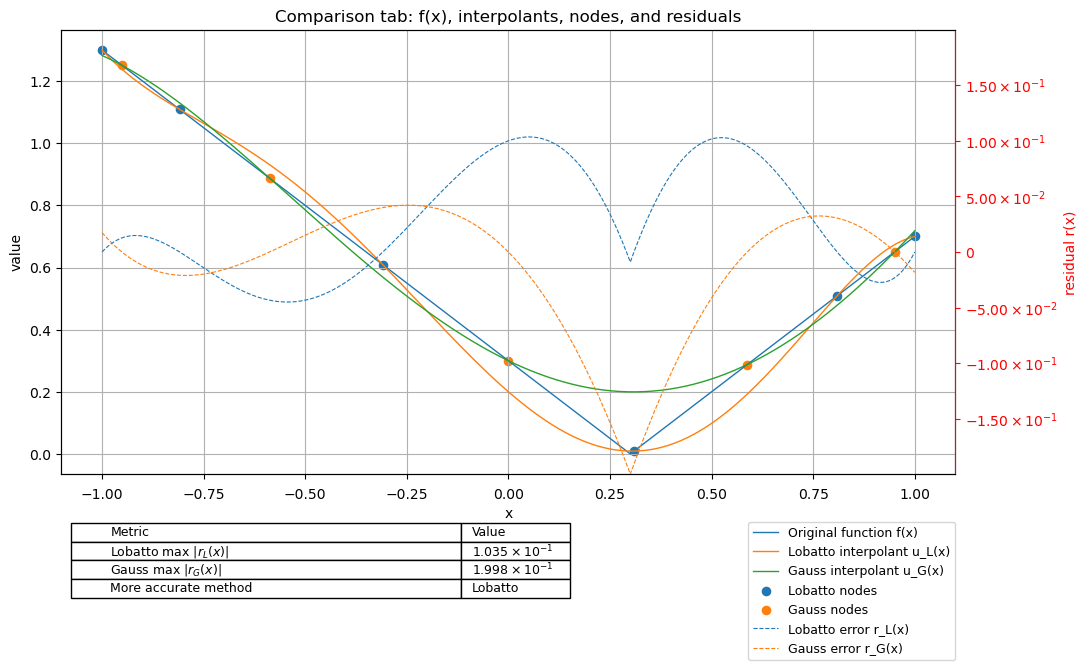

In [11]:
plot_comparison_interactive(prefix="compare_")